1.IMPORTING LIBRARIES,MODULES AND PACKAGES

In [365]:
#first we start by importing the needed modules for the model
import numpy as np
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

Load csv file

In [366]:
df=pd.read_csv("BP dataset.csv")
data=df

Data Preprocessing (Cleaning the data)

In [367]:
df.head()

,Num,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension
0,1,2,Female,45,152,63,161,89,97,27.27,1
1,2,3,Female,50,157,50,160,93,76,20.28,1
2,3,6,Female,47,150,47,101,71,79,20.89,0
3,4,8,Male,45,172,65,136,93,87,21.97,0
4,5,9,Female,46,155,65,123,73,73,27.06,0


In [368]:
df.tail()

,Num,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension
214,215,415,Male,24,180,70,111,70,77,21.60,0
215,216,416,Female,25,156,47,93,57,79,19.31,0
216,217,417,Male,25,176,55,120,69,72,17.76,0
217,218,418,Male,25,173,63,106,69,67,21.05,0
218,219,419,Male,24,175,58,108,68,65,18.94,0


In [369]:
df.shape

(219, 11)

In [370]:
df.duplicated().any()

False

In [371]:
df.notnull().any()

Num                               True
subject_ID                        True
Sex(M/F)                          True
Age(year)                         True
Height(cm)                        True
Weight(kg)                        True
Systolic Blood Pressure(mmHg)     True
Diastolic Blood Pressure(mmHg)    True
Heart Rate(b/m)                   True
BMI(kg/m^2)                       True
Hypertension                      True
dtype: bool

In [372]:
df.describe()

,Num,subject_ID,Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,110.000000,156.598174,57.168950,161.228311,60.191781,127.945205,71.849315,73.639269,23.107215,0.246575
std,63.364028,101.604347,15.874327,8.202871,11.886301,20.377779,11.111203,10.738874,4.004302,0.432005
min,1.000000,2.000000,21.000000,145.000000,36.000000,80.000000,42.000000,52.000000,14.690000,0.000000
25%,55.500000,85.500000,48.000000,155.000000,52.500000,113.500000,64.000000,66.000000,20.550000,0.000000
50%,110.000000,152.000000,58.000000,160.000000,60.000000,126.000000,70.000000,73.000000,22.600000,0.000000
75%,164.500000,214.500000,67.500000,167.000000,66.500000,139.000000,78.000000,80.000000,25.000000,0.000000
max,219.000000,419.000000,86.000000,196.000000,103.000000,182.000000,107.000000,106.000000,37.460000,1.000000


In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Num                             219 non-null    int64  
 1   subject_ID                      219 non-null    int64  
 2   Sex(M/F)                        219 non-null    object 
 3   Age(year)                       219 non-null    int64  
 4   Height(cm)                      219 non-null    int64  
 5   Weight(kg)                      219 non-null    int64  
 6   Systolic Blood Pressure(mmHg)   219 non-null    int64  
 7   Diastolic Blood Pressure(mmHg)  219 non-null    int64  
 8   Heart Rate(b/m)                 219 non-null    int64  
 9   BMI(kg/m^2)                     219 non-null    float64
 10  Hypertension                    219 non-null    int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 18.9+ KB


In [374]:
df.columns

Index(['Num', 'subject_ID', 'Sex(M/F)', 'Age(year)', 'Height(cm)',
       'Weight(kg)', 'Systolic Blood Pressure(mmHg)',
       'Diastolic Blood Pressure(mmHg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)',
       'Hypertension'],
      dtype='object')

In [375]:
df.columns = ['Num', 'subject_ID', 'Sex', 'Age',
       'Height', 'Weight', 'Systolic_Blood_Pressure', 'Diastolic_Blood_Pressure',
       'Heart_Rate', 'BMI','Hypertension']
df.columns

Index(['Num', 'subject_ID', 'Sex', 'Age', 'Height', 'Weight',
       'Systolic_Blood_Pressure', 'Diastolic_Blood_Pressure', 'Heart_Rate',
       'BMI', 'Hypertension'],
      dtype='object')

<Axes: xlabel='Sex', ylabel='count'>

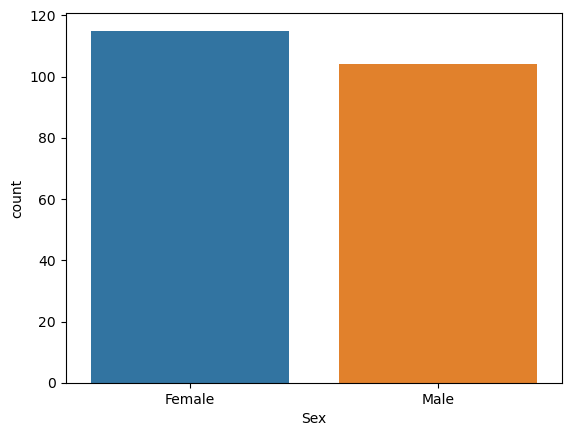

In [376]:
sns.countplot(x=df.Sex)

<Axes: xlabel='Hypertension', ylabel='count'>

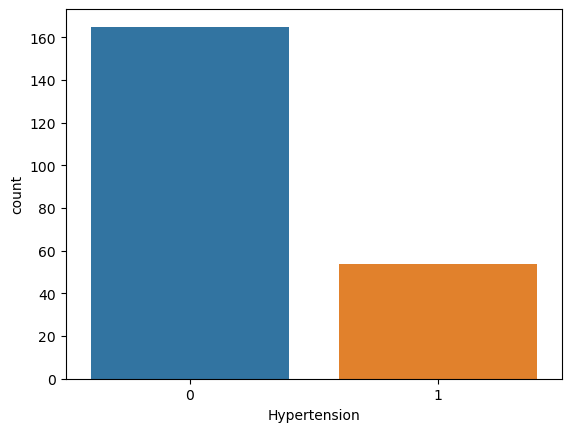

In [377]:
sns.countplot(x=df.Hypertension)

Encoding Categorical Data

In [378]:
data.drop(columns=['Num', 'subject_ID'], inplace=True)
data.head()

,Sex,Age,Height,Weight,Systolic_Blood_Pressure,Diastolic_Blood_Pressure,Heart_Rate,BMI,Hypertension
0,Female,45,152,63,161,89,97,27.27,1
1,Female,50,157,50,160,93,76,20.28,1
2,Female,47,150,47,101,71,79,20.89,0
3,Male,45,172,65,136,93,87,21.97,0
4,Female,46,155,65,123,73,73,27.06,0


In [379]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

Encoding Independent Variable

In [380]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))
print(X)

[[1.0 0.0 45 ... 89 97 27.27]
 [1.0 0.0 50 ... 93 76 20.28]
 [1.0 0.0 47 ... 71 79 20.89]
 ...
 [0.0 1.0 25 ... 69 72 17.76]
 [0.0 1.0 25 ... 69 67 21.05]
 [0.0 1.0 24 ... 68 65 18.94]]


Encoding Dependent Variable (Target)

In [381]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

Spliting Data

In [382]:
from sklearn.model_selection import train_test_split
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling 

In [383]:
sc = StandardScaler()
X_train[:, 2:] = sc.fit_transform(X_train[:, 2:])
X_test[:, 2:] = sc.transform(X_test[:, 2:])

Model Training

In [384]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [385]:
y_pred_train = lr.predict(X_train)
accuracy_score(y_train, y_pred_train)

0.9885714285714285

In [386]:
y_pred_test = lr.predict(X_test)
accuracy_score(y_test, y_pred_test)

0.9772727272727273

In [387]:
print(classification_report(y_test, y_pred_test, labels=[0, 1], target_names=['Normal', 'High']))


              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99        35
        High       1.00      0.89      0.94         9

    accuracy                           0.98        44
   macro avg       0.99      0.94      0.96        44
weighted avg       0.98      0.98      0.98        44



Using Descision TRee Classifier

In [388]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy')
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [389]:
y_pred_train_dt = dt.predict(X_train)
print(f'Train : {accuracy_score(y_train, y_pred_train_dt)}')

y_pred_test_dt = dt.predict(X_test)
print(f'Test : {accuracy_score(y_test, y_pred_test_dt)}')

Train : 1.0
Test : 1.0


In [390]:
print(classification_report(y_test, y_pred_test_dt, labels=[0, 1], target_names=['Normal', 'High']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        35
        High       1.00      1.00      1.00         9

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44



Using Extreme Gradient Classifier

In [391]:
# Define the model parameters
xgb_model = xgb.XGBClassifier()

# For classification problems, use objective="binary:logistic" or other options

In [392]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [393]:
from sklearn.model_selection import GridSearchCV

In [394]:
param_grid_xgb = {
     'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [100, 200, 300]
}
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5)
grid_search_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...e,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]})

In [395]:
best_params_xgb = grid_search_xgb.best_params_
best_model_xgb = grid_search_xgb.best_estimator_

accuracy_xgb_train = best_model_xgb.score(X_train, y_train)
accuracy_xgb_test = best_model_xgb.score(X_test, y_test)

print("Best Hyperparameters for XGBoost:", best_params_xgb)
print("XGBoost Train Accuracy:", accuracy_xgb_train)
print(f"XGBoost Test Accuracy: {np.round(accuracy_xgb_test*100):.2f}%")

Best Hyperparameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGBoost Train Accuracy: 1.0
XGBoost Test Accuracy: 100.00%
